In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

df = pd.read_csv('worldometer_coronavirus_summary_data.csv')


print("First 5 Rows")
display(df.head())


print("\nShape of Dataset:")
print(df.shape)


print("\nData Types:")
print(df.dtypes)


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDuplicate Rows:")
print(df.duplicated().sum())


print("\nStatistical Summary")
display(df.describe())


First 5 Rows


,country,continent,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
0,Afghanistan,Asia,179267,7690.0,162202.0,9375.0,1124.0,4420,190.0,951337.0,23455.0,40560636
1,Albania,Europe,275574,3497.0,271826.0,251.0,2.0,95954,1218.0,1817530.0,632857.0,2871945
2,Algeria,Africa,265816,6875.0,178371.0,80570.0,6.0,5865,152.0,230861.0,5093.0,45325517
3,Andorra,Europe,42156,153.0,41021.0,982.0,14.0,543983,1974.0,249838.0,3223924.0,77495
4,Angola,Africa,99194,1900.0,97149.0,145.0,NaN,2853,55.0,1499795.0,43136.0,34769277



Shape of Dataset:
(226, 12)

Data Types:
country                            object
continent                          object
total_confirmed                     int64
total_deaths                      float64
total_recovered                   float64
active_cases                      float64
serious_or_critical               float64
total_cases_per_1m_population       int64
total_deaths_per_1m_population    float64
total_tests                       float64
total_tests_per_1m_population     float64
population                          int64
dtype: object

Missing Values:
country                            0
continent                          0
total_confirmed                    0
total_deaths                       8
total_recovered                   22
active_cases                      22
serious_or_critical               81
total_cases_per_1m_population      0
total_deaths_per_1m_population     8
total_tests                       14
total_tests_per_1m_population     14
population      

,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
count,2.260000e+02,2.180000e+02,2.040000e+02,2.040000e+02,145.000000,226.000000,218.000000,2.120000e+02,2.120000e+02,2.260000e+02
mean,2.305651e+06,2.884442e+04,2.256851e+06,6.861029e+04,269.482759,148156.809735,1157.550459,2.987445e+07,1.944650e+06,3.495521e+07
std,7.575510e+06,9.971254e+04,7.613357e+06,2.350430e+05,883.174727,155202.909225,1212.833590,1.079635e+08,3.318400e+06,1.390338e+08
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000,16.000000,2.000000,5.117000e+03,5.093000e+03,8.050000e+02
25%,2.412600e+04,2.370000e+02,1.619300e+04,2.397500e+02,5.000000,11748.250000,172.500000,3.472968e+05,1.667260e+05,5.605125e+05
50%,1.793750e+05,2.251500e+03,1.372740e+05,1.634000e+03,17.000000,98271.500000,768.000000,2.238918e+06,7.753355e+05,5.800570e+06
75%,1.090902e+06,1.400650e+04,1.006245e+06,1.929675e+04,139.000000,255632.750000,1850.000000,1.233862e+07,2.267408e+06,2.187284e+07
max,8.420947e+07,1.026646e+06,8.124426e+07,1.938567e+06,8318.000000,704302.000000,6297.000000,1.016883e+09,2.184247e+07,1.439324e+09


# **SUMMARY**
1. The dataset contains COVID-19 statistics for different countries.
2. It has 226 rows and 12 columns.
3. The dataset includes total cases, deaths, recoveries, active cases and testing information.
4. Missing values and duplicate records are checked before analysis.
5. The dataset will be cleaned before performing exploratory analysis and visualization.

In [6]:
#DATA CLEANING

df = df.drop_duplicates()

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('+', '', regex=False)
            .str.replace(' ', '', regex=False)
        )

for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Cleaned Dataset")
display(df.head())

print(df.info())

Cleaned Dataset


,country,continent,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
0,Afghanistan,Asia,179267,7690.0,162202.0,9375.0,1124.0,4420,190.0,951337.0,23455.0,40560636
1,Albania,Europe,275574,3497.0,271826.0,251.0,2.0,95954,1218.0,1817530.0,632857.0,2871945
2,Algeria,Africa,265816,6875.0,178371.0,80570.0,6.0,5865,152.0,230861.0,5093.0,45325517
3,Andorra,Europe,42156,153.0,41021.0,982.0,14.0,543983,1974.0,249838.0,3223924.0,77495
4,Angola,Africa,99194,1900.0,97149.0,145.0,17.0,2853,55.0,1499795.0,43136.0,34769277


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         226 non-null    object 
 1   continent                       226 non-null    object 
 2   total_confirmed                 226 non-null    int64  
 3   total_deaths                    226 non-null    float64
 4   total_recovered                 226 non-null    float64
 5   active_cases                    226 non-null    float64
 6   serious_or_critical             226 non-null    float64
 7   total_cases_per_1m_population   226 non-null    int64  
 8   total_deaths_per_1m_population  226 non-null    float64
 9   total_tests                     226 non-null    float64
 10  total_tests_per_1m_population   226 non-null    float64
 11  population                      226 non-null    int64  
dtypes: float64(7), int64(3), object(2)
m

# **DATA CLEANING DOCUMENTATION**

1. Duplicate rows were removed to avoid repeated observations.

2. Unnecessary unnamed columns were removed.

3. Numeric columns containing commas (+ or spaces) were converted into numbers.

4. Missing numerical values were replaced using the median because it is less affected by outliers.

5. Missing categorical values were replaced with 'Unknown'.

6. Correct data types were assigned for numerical analysis.

# **Which countries have the highest total cases?**

In [12]:
top_cases = df[['country','active_cases']].sort_values(
    by='active_cases',
    ascending=False
).head(10)

print(top_cases)

       country  active_cases
216        USA     1938567.0
78     Germany     1685607.0
220    VietNam     1298525.0
101      Italy      998118.0
72      France      856871.0
200     Taiwan      706841.0
160     Poland      552117.0
191      Spain      473589.0
10   Australia      386179.0
131     Mexico      376294.0


# **Which countries have the highest deaths?**

In [15]:
top_deaths = df[['country','total_deaths']].sort_values(
    by='total_deaths',
    ascending=False
).head(10)

print(top_deaths)

       country  total_deaths
216        USA     1026646.0
26      Brazil      664920.0
94       India      524214.0
165     Russia      377670.0
131     Mexico      324465.0
158       Peru      213023.0
212         UK      176708.0
101      Italy      165244.0
95   Indonesia      156458.0
72      France      147257.0


# **What are the average statistics?**

In [16]:
display(df.describe())

,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
count,2.260000e+02,2.260000e+02,2.260000e+02,2.260000e+02,226.000000,226.000000,226.000000,2.260000e+02,2.260000e+02,2.260000e+02
mean,2.305651e+06,2.790308e+04,2.050521e+06,6.209048e+04,178.991150,148156.809735,1143.761062,2.816251e+07,1.872214e+06,3.495521e+07
std,7.575510e+06,9.804760e+04,7.258939e+06,2.241414e+05,716.883849,155202.909225,1193.259769,1.047637e+08,3.225896e+06,1.390338e+08
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000,16.000000,2.000000,5.117000e+03,5.093000e+03,8.050000e+02
25%,2.412600e+04,2.797500e+02,2.024325e+04,2.845000e+02,10.000000,11748.250000,174.750000,4.005950e+05,1.887170e+05,5.605125e+05
50%,1.793750e+05,2.251500e+03,1.372740e+05,1.634000e+03,17.000000,98271.500000,768.000000,2.238918e+06,7.753355e+05,5.800570e+06
75%,1.090902e+06,1.323375e+04,8.581695e+05,1.468400e+04,42.750000,255632.750000,1842.750000,1.117836e+07,1.987618e+06,2.187284e+07
max,8.420947e+07,1.026646e+06,8.124426e+07,1.938567e+06,8318.000000,704302.000000,6297.000000,1.016883e+09,2.184247e+07,1.439324e+09


# **Which continent has the highest total cases?**

In [25]:
continent_cases = df.groupby('continent')['active_cases'].sum().sort_values(ascending=False)
print(continent_cases)

continent
Europe               5854904.0
NorthAmerica         3332417.0
Asia                 3265220.0
SouthAmerica          616868.0
Africa                505936.0
Australia/Oceania     457103.0
Name: active_cases, dtype: float64


# **Which countries performed the most tests?**

In [27]:
tests = df[['country','total_tests']].sort_values(
        by='total_tests',
        ascending=False
    ).head(10)
print(tests)

     country   total_tests
216      USA  1.016883e+09
94     India  8.438369e+08
212       UK  5.192641e+08
191    Spain  4.710363e+08
165   Russia  2.734000e+08
72    France  2.714902e+08
101    Italy  2.178537e+08
11   Austria  1.850349e+08
209   Turkey  1.606227e+08
44     China  1.600000e+08


# **Visualization**

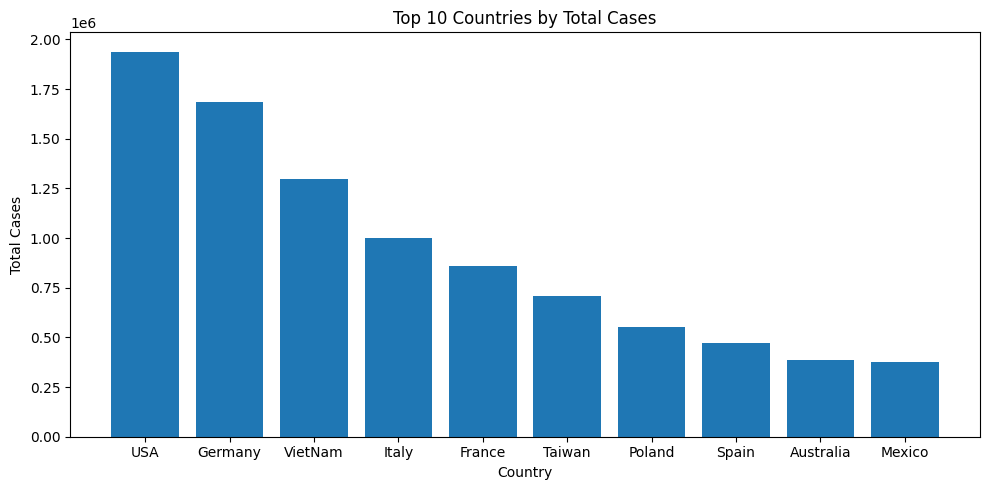

In [34]:
plt.figure(figsize=(10,5))
plt.bar(top_cases['country'],
        top_cases['active_cases'])


plt.title("Top 10 Countries by Total Cases")

plt.xlabel("Country")

plt.ylabel("Total Cases")
plt.tight_layout()

plt.show()

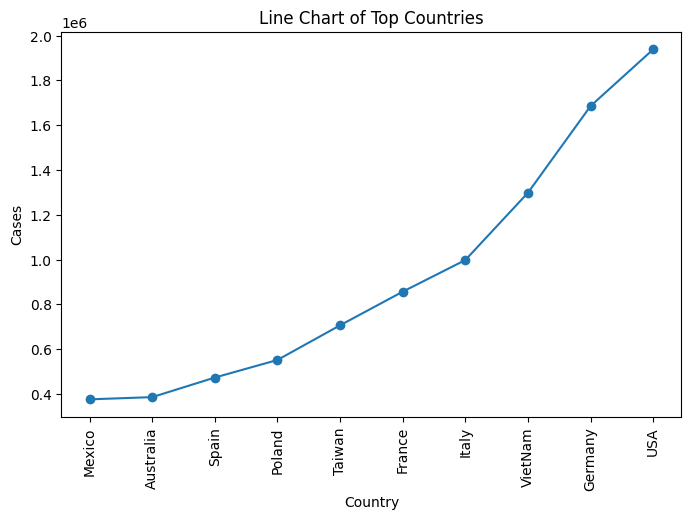

In [37]:
line = top_cases.sort_values('active_cases')

plt.figure(figsize=(8,5))

plt.plot(line['country'],
         line['active_cases'],
         marker='o')


plt.title("Line Chart of Top Countries")

plt.xlabel("Country")

plt.ylabel("Cases")

plt.show()

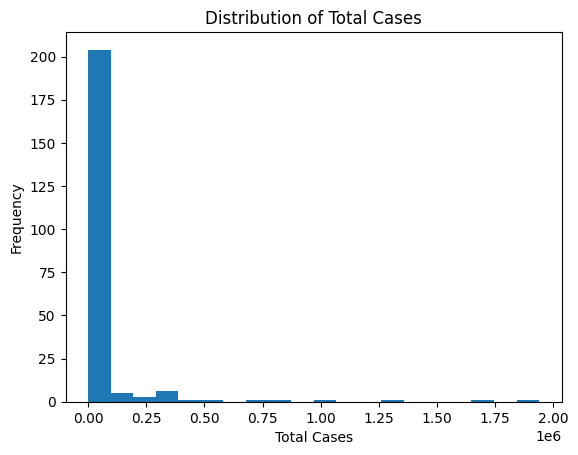

In [40]:
plt.hist(df['active_cases'], bins=20)

plt.title("Distribution of Total Cases")

plt.xlabel("Total Cases")

plt.ylabel("Frequency")

plt.show()

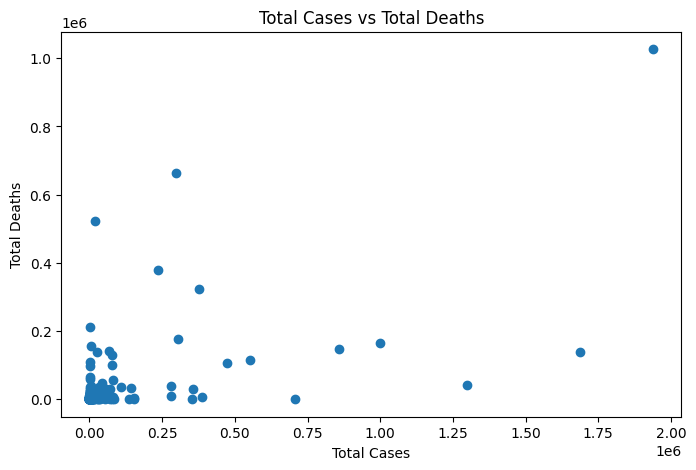

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(df['active_cases'],
            df['total_deaths'])

plt.title("Total Cases vs Total Deaths")

plt.xlabel("Total Cases")

plt.ylabel("Total Deaths")

plt.show()

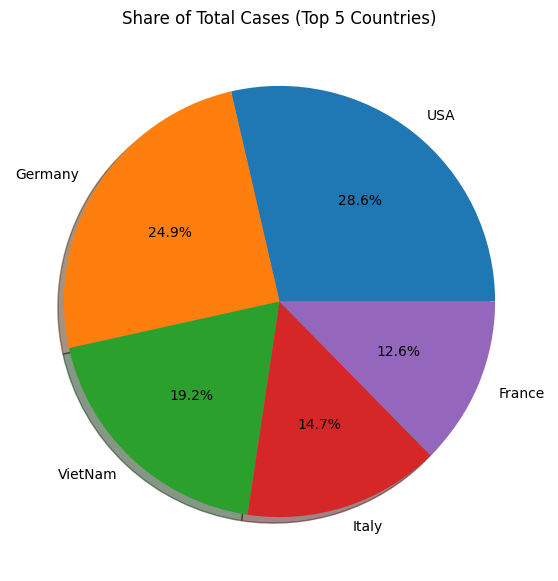

In [53]:
pie = top_cases.head(5)

plt.figure(figsize=(7,7))

plt.pie(
    pie['active_cases'],
    labels=pie['country'],
    autopct='%1.1f%%',shadow=True

)

plt.title("Share of Total Cases (Top 5 Countries)")

plt.show()

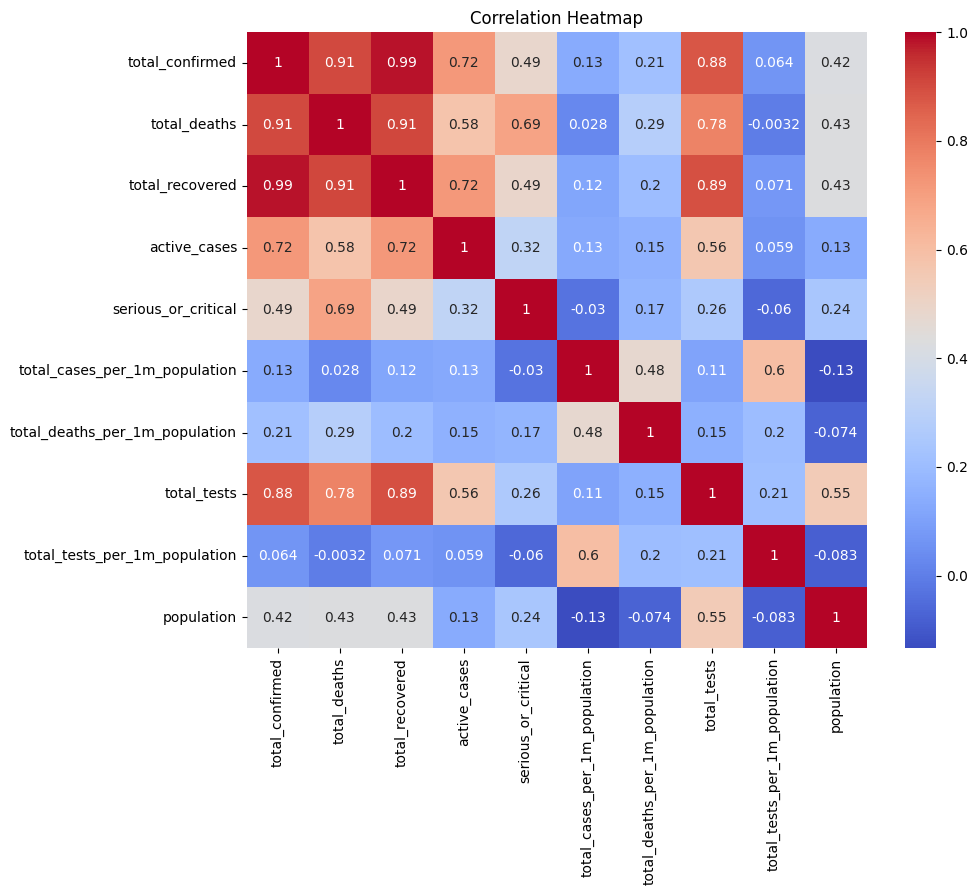

In [54]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# **INSIGHTS REPORT**

1. The bar chart shows the countries with the highest COVID-19 cases.

2. The scatter plot indicates a positive relationship between total cases and total deaths.

3. The histogram shows that most countries reported relatively lower case counts while only a few countries had extremely high numbers.

4. The heatmap reveals strong correlations between Total Cases, Total Deaths, and Total Recoveries.

5. The pie chart demonstrates that a small number of countries account for a large proportion of global COVID-19 cases.
